Hypothesis(H1): Brain regions exhibit unique connectivity fingerprints at rest enabling, accurate region identification from connectivity patterns. 

In [2]:
# =============================================================================
# One-vs-Rest Brain Region Classification
# =============================================================================

try:
    import numpy as np
    import pandas as pd
    import json
    from pathlib import Path
    import warnings
    import re

    # Visualization
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    import plotly.express as px

    # Machine Learning
    from sklearn.metrics import confusion_matrix

    # Configuration
    warnings.filterwarnings('ignore')
    pd.set_option('display.max_columns', None)
    pd.set_option('display.precision', 2)

    # Color Palette for Visualizations
    COLORS = {
        'baseline': '#e74c3c',      # Red
        'step1': '#f39c12',          # Orange  
        'step2': '#3498db',          # Blue
        'step3': '#2ecc71',          # Green
        'same_h_same_n': '#1A5276',
        'same_h_diff_n': '#1D8348',
        'diff_h_same_n': '#7D3C98',
        'diff_h_diff_n': '#2E4053'
    }
    print("Imports successful.")
except Exception as e:
    print(f"Import Error: {e}")

Imports successful.


In [3]:
# =============================================================================
# PATH VERIFICATION
# =============================================================================


BASE_PATH = Path('/home/sjoon/projects/brain_connectivity_classifier/data')
RESULTS_DIR = BASE_PATH / 'results'

# Template for repetitive paths
def res_p(sub, task): return RESULTS_DIR / sub / task
f_sub = 'full_connectivity_analysis'
l_sub, r_sub = 'hemisphere_analysis/left_hemisphere', 'hemisphere_analysis/right_hemisphere'
ovr, t_ovr = 'one_vs_rest', 'task_testing_one_vs_rest'

PATHS = {
    'full_cv': res_p(f_sub, ovr) / 'cv_summary.json',
    'full_task': res_p(f_sub, t_ovr) / 'task_testing_summary.json',
    'full_pred': res_p(f_sub, t_ovr) / 'task_predictions.npy',
    'full_true': res_p(f_sub, t_ovr) / 'task_true_labels.npy',
    
    'left_cv': res_p(l_sub, ovr) / 'cv_summary.json',
    'left_task': res_p(l_sub, t_ovr) / 'task_testing_summary.json',
    'left_pred': res_p(l_sub, t_ovr) / 'task_predictions.npy',
    'left_true': res_p(l_sub, t_ovr) / 'task_true_labels.npy',
    
    'right_cv': res_p(r_sub, ovr) / 'cv_summary.json',
    'right_task': res_p(r_sub, t_ovr) / 'task_testing_summary.json',
    'right_pred': res_p(r_sub, t_ovr) / 'task_predictions.npy',
    'right_true': res_p(r_sub, t_ovr) / 'task_true_labels.npy',
    
    'full_regions': BASE_PATH / 'FULL_region_info.csv',
    'lh_regions': BASE_PATH / 'LH_region_info.csv',
    'rh_regions': BASE_PATH / 'RH_region_info.csv',
    'coordinates': BASE_PATH / 'network_files' / 'Schaefer2018_200Parcels_Tian_32Parcels.csv'
}

# Condensed Verification
print("Path Verification:")
missing_paths = [n for n, p in PATHS.items() if not (print(f"  {'✓' if p.exists() else '✗'} {n}{'' if p.exists() else ' - MISSING'}") or p.exists())]

if missing_paths: print(f"\n⚠ Warning: {len(missing_paths)} path(s) missing")
else: print("\n✓ All paths verified successfully")

Path Verification:
  ✓ full_cv
  ✓ full_task
  ✓ full_pred
  ✓ full_true
  ✓ left_cv
  ✓ left_task
  ✓ left_pred
  ✓ left_true
  ✓ right_cv
  ✓ right_task
  ✓ right_pred
  ✓ right_true
  ✓ full_regions
  ✓ lh_regions
  ✓ rh_regions
  ✓ coordinates

✓ All paths verified successfully


In [4]:
# =============================================================================
# DATA LOADING
# =============================================================================
print("Loading data...\n")

# 1. Load region metadata
full_region_info = pd.read_csv(PATHS['full_regions'])
lh_region_info = pd.read_csv(PATHS['lh_regions'])
rh_region_info = pd.read_csv(PATHS['rh_regions'])
coords_df = pd.read_csv(PATHS['coordinates'])

print(f"✓ Metadata loaded: Full ({len(full_region_info)}), Left ({len(lh_region_info)}), Right ({len(rh_region_info)})")

# 2. Load performance summaries
def load_summary(path):
    with open(path, 'r') as f: return json.load(f)

s_keys = ['full_cv', 'full_task', 'left_cv', 'left_task', 'right_cv', 'right_task']
full_cv, full_task, left_cv, left_task, right_cv, right_task = [load_summary(PATHS[k]) for k in s_keys]

# 3. Load predictions and labels
p_keys = [('full_pred', 'full_true'), ('left_pred', 'left_true'), ('right_pred', 'right_true')]
preds_data = [ (np.load(PATHS[p], allow_pickle=True), np.load(PATHS[t], allow_pickle=True)) for p, t in p_keys]

(full_preds, full_true), (left_preds, left_true), (right_preds, right_true) = preds_data



print(f"\n✓ Summaries and Predictions loaded:")
print(f"  Full: {len(full_preds):,} | Left: {len(left_preds):,} | Right: {len(right_preds):,}")
print(f"\n DATA LOADING COMPLETE")

Loading data...

✓ Metadata loaded: Full (232), Left (116), Right (116)

✓ Summaries and Predictions loaded:
  Full: 46,400 | Left: 23,200 | Right: 23,200

 DATA LOADING COMPLETE


In [5]:
# =============================================================================
# CROSS-VALIDATION PERFORMANCE SUMMARY TABLE
# =============================================================================

def extract_cv_metrics(cv_summary, region_info):
    """Extract key metrics from CV summary"""
    
    # Get overall metrics
    overall = cv_summary['overall_metrics']
    n_samples = overall['n_samples']
    n_classes = overall['n_classes']
    
    # Mean validation accuracy (top-level)
    mean_acc = cv_summary['mean_val_accuracy']
    
    # Extract fold accuracies and calculate std, min, max
    fold_accs = [fold['val_accuracy'] for fold in cv_summary['fold_metrics']]
    std_acc = np.std(fold_accs)
    min_acc = min(fold_accs)
    max_acc = max(fold_accs)
    
    # Chance level (1 / number of classes)
    chance_level = 1 / n_classes
    
    # Fold above chance
    fold_above_chance = mean_acc / chance_level
    
    return {
        'n_regions': n_classes,  # n_classes corresponds to n_regions
        'n_samples': n_samples,
        'mean_acc': mean_acc,
        'std_acc': std_acc,
        'min_acc': min_acc,
        'max_acc': max_acc,
        'chance_level': chance_level,
        'fold_above_chance': fold_above_chance
    }

# Extract metrics for each model
full_metrics = extract_cv_metrics(full_cv, full_region_info)
left_metrics = extract_cv_metrics(left_cv, lh_region_info)
right_metrics = extract_cv_metrics(right_cv, rh_region_info)

# Create summary table
summary_data = {
    'Model': ['Full connectivity', 'Left hemisphere', 'Right hemisphere'],
    'N Regions': [full_metrics['n_regions'], left_metrics['n_regions'], right_metrics['n_regions']],
    'N Samples': [f"{full_metrics['n_samples']:,}", f"{left_metrics['n_samples']:,}", f"{right_metrics['n_samples']:,}"],
    'Mean CV Accuracy': [f"{full_metrics['mean_acc']:.1%}", f"{left_metrics['mean_acc']:.1%}", f"{right_metrics['mean_acc']:.1%}"],
    'Std Across Folds': [f"{full_metrics['std_acc']:.1%}", f"{left_metrics['std_acc']:.1%}", f"{right_metrics['std_acc']:.1%}"],
    'Range': [
        f"{full_metrics['min_acc']:.1%}-{full_metrics['max_acc']:.1%}",
        f"{left_metrics['min_acc']:.1%}-{left_metrics['max_acc']:.1%}",
        f"{right_metrics['min_acc']:.1%}-{right_metrics['max_acc']:.1%}"
    ],
    'Chance level': [f"{full_metrics['chance_level']:.2%}", f"{left_metrics['chance_level']:.2%}", f"{right_metrics['chance_level']:.2%}"],
    'Fold Above chance': [f"{full_metrics['fold_above_chance']:.0f}x", f"{left_metrics['fold_above_chance']:.0f}x", f"{right_metrics['fold_above_chance']:.0f}x"]
}

cv_summary_table = pd.DataFrame(summary_data)

# Display with nice formatting
print("\n" + "="*100)
print("CROSS-VALIDATION PERFORMANCE SUMMARY")
print("="*100 + "\n")
display(cv_summary_table)


CROSS-VALIDATION PERFORMANCE SUMMARY



,Model,N Regions,N Samples,Mean CV Accuracy,Std Across Folds,Range,Chance level,Fold Above chance
0,Full connectivity,232,"51,968",76.2%,0.7%,75.2%-77.4%,0.43%,177x
1,Left hemisphere,116,"25,984",92.8%,0.6%,91.8%-93.3%,0.86%,108x
2,Right hemisphere,116,"25,984",92.5%,0.3%,91.9%-92.9%,0.86%,107x


In [6]:
import os
os.getcwd()

'/home/sjoon/projects/brain_connectivity_classifier/analysis/JupyterFiles'

Unique network names in full_region_info:
['VisCent' 'VisPeri' 'SomMotA' 'SomMotB' 'DorsAttnA' 'DorsAttnB'
 'SalVentAttnA' 'SalVentAttnB' 'LimbicB' 'LimbicA' 'ContA' 'ContB' 'ContC'
 'DefaultA' 'DefaultB' 'DefaultC' 'TempPar' 'Hippocampus_ant'
 'Hippocampus_post' 'Amygdala_lat' 'Amygdala_med' 'Thalamus_DP'
 'Thalamus_VP' 'Thalamus_VA' 'Thalamus_DA' 'Accumbens_shell'
 'Accumbens_core' 'Pallidum_post' 'Pallidum_ant' 'Putamen_ant'
 'Putamen_post' 'Caudate_ant' 'Caudate_post']
Total unique networks: 33

Mapped categories and their counts:
  Attention: 48 regions
  Control: 37 regions
  Default Mode: 37 regions
  Limbic: 14 regions
  Somatomotor: 34 regions
  Subcortical: 32 regions
  Temporal-Parietal: 6 regions
  Visual: 24 regions



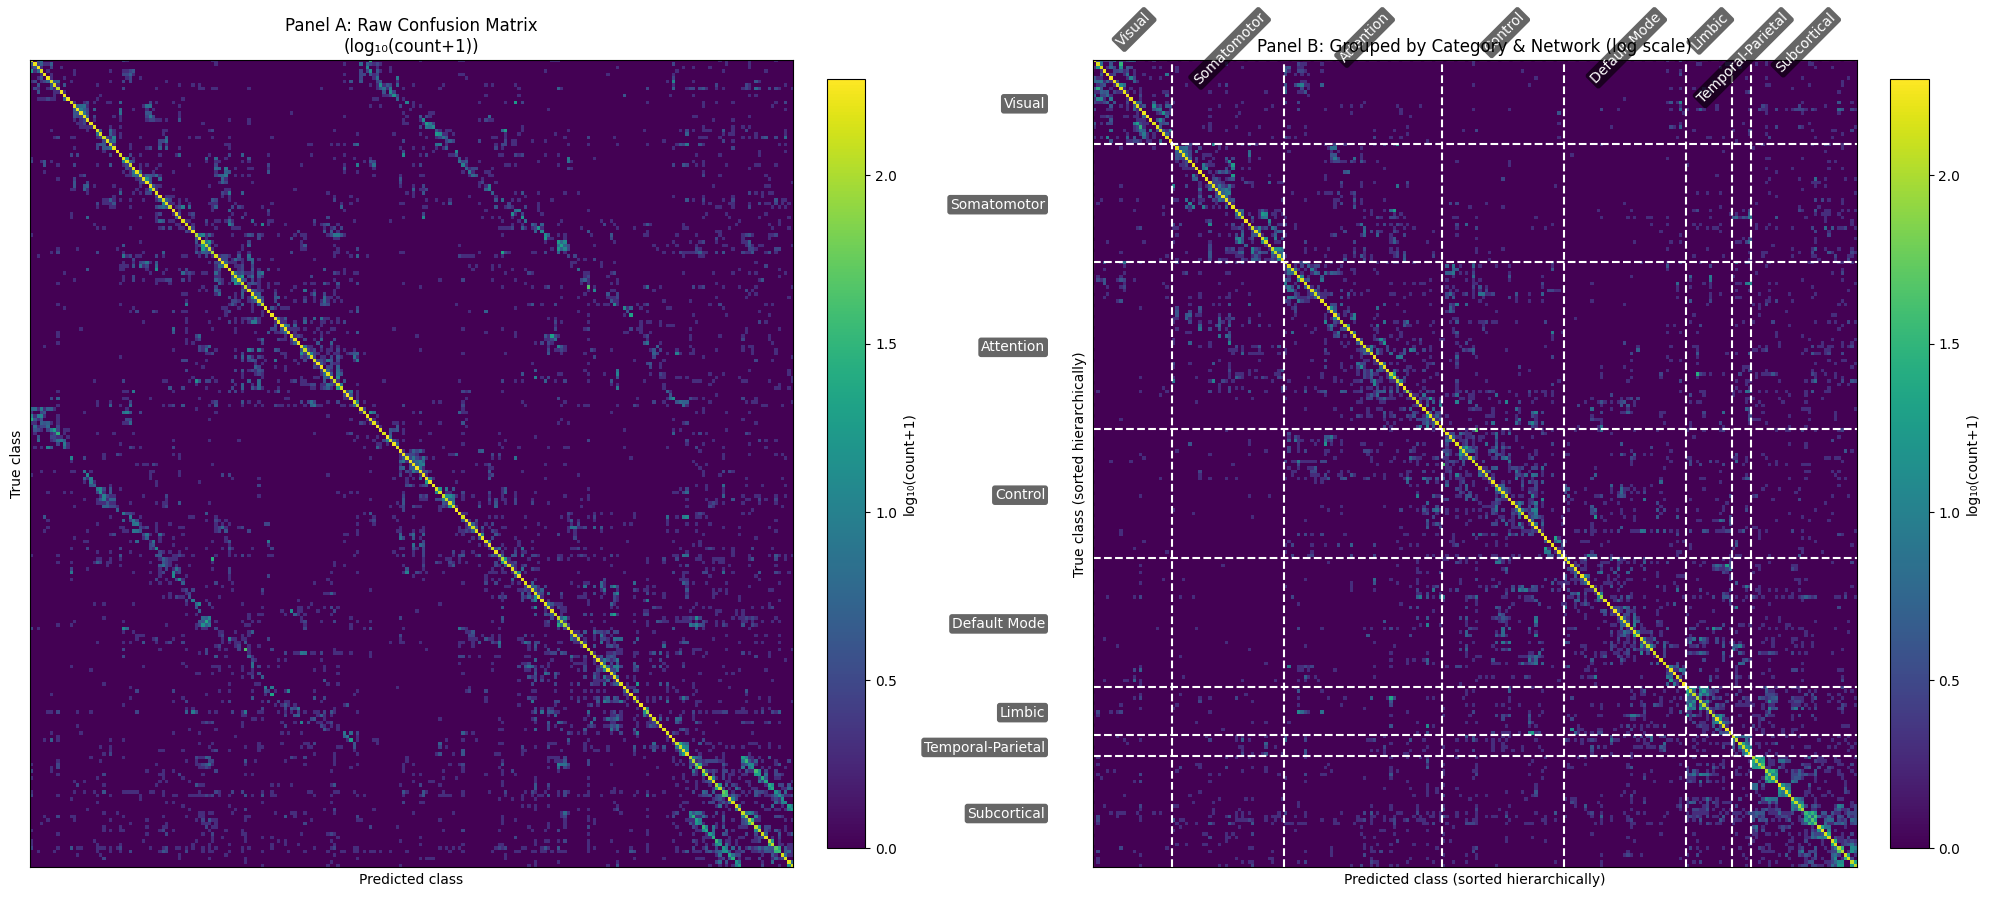

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# -----------------------------------------------------------------------------
# 1. Compute raw confusion matrix
# -----------------------------------------------------------------------------
cm = confusion_matrix(full_true, full_preds)          # shape (232, 232)

# -----------------------------------------------------------------------------
# 2. Inspect unique network names (to verify mapping)
# -----------------------------------------------------------------------------
unique_nets = full_region_info['network'].unique()
print("Unique network names in full_region_info:")
print(unique_nets)
print(f"Total unique networks: {len(unique_nets)}\n")

# -----------------------------------------------------------------------------
# 3. Define mapping from original network names to the eight categories
# -----------------------------------------------------------------------------
cortical_networks = [
    'VisCent', 'VisPeri',
    'SomMotA', 'SomMotB',
    'DorsAttnA', 'DorsAttnB', 'SalVentAttnA', 'SalVentAttnB',
    'ContA', 'ContB', 'ContC',
    'DefaultA', 'DefaultB', 'DefaultC',
    'LimbicA', 'LimbicB',
    'TempPar'
]

network_to_category = {
    # Visual
    'VisCent': 'Visual',
    'VisPeri': 'Visual',
    # Somatomotor
    'SomMotA': 'Somatomotor',
    'SomMotB': 'Somatomotor',
    # Attention
    'DorsAttnA': 'Attention',
    'DorsAttnB': 'Attention',
    'SalVentAttnA': 'Attention',
    'SalVentAttnB': 'Attention',
    # Control
    'ContA': 'Control',
    'ContB': 'Control',
    'ContC': 'Control',
    # Default Mode
    'DefaultA': 'Default Mode',
    'DefaultB': 'Default Mode',
    'DefaultC': 'Default Mode',
    # Limbic
    'LimbicA': 'Limbic',
    'LimbicB': 'Limbic',
    # Temporal-Parietal
    'TempPar': 'Temporal-Parietal',
}

# -----------------------------------------------------------------------------
# 4. Apply mapping: use dictionary, then fallback to 'Subcortical' for unknowns
# -----------------------------------------------------------------------------
orig_networks = full_region_info['network'].values
categories = []
for net in orig_networks:
    if net in network_to_category:
        categories.append(network_to_category[net])
    else:
        categories.append('Subcortical')
categories = np.array(categories)

# -----------------------------------------------------------------------------
# 5. Verify category counts
# -----------------------------------------------------------------------------
print("Mapped categories and their counts:")
unique_cats, counts = np.unique(categories, return_counts=True)
for cat, cnt in zip(unique_cats, counts):
    print(f"  {cat}: {cnt} regions")
print()

# -----------------------------------------------------------------------------
# 6. Define the desired category order (from your table)
# -----------------------------------------------------------------------------
category_order = [
    'Visual',
    'Somatomotor',
    'Attention',
    'Control',
    'Default Mode',
    'Limbic',
    'Temporal-Parietal',
    'Subcortical'
]

# Convert to ordered categorical
cat_series = pd.Categorical(categories, categories=category_order, ordered=True)

# -----------------------------------------------------------------------------
# 7. Create a sort order that groups by category, then by original network,
#    then by region name
# -----------------------------------------------------------------------------
df_classes = pd.DataFrame({
    'category': cat_series,
    'original_network': full_region_info['network'].values,
    'region_name': full_region_info['region_name'].values,
    'class_idx': np.arange(len(categories))
})

df_classes_sorted = df_classes.sort_values(['category', 'original_network', 'region_name'])
sort_idx = df_classes_sorted['class_idx'].values      # indices to reorder rows/cols

# Get the start indices of each category group in the sorted order
sorted_categories = df_classes_sorted['category'].values
category_starts = []
current_cat = None
for i, cat in enumerate(sorted_categories):
    if cat != current_cat:
        category_starts.append(i)
        current_cat = cat
category_starts.append(len(sorted_categories))        # add end index

# -----------------------------------------------------------------------------
# 8. Create figure with two panels
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Panel A: Raw confusion matrix (log scale)
im1 = axes[0].imshow(np.log10(cm + 1), cmap='viridis', interpolation='nearest', aspect='auto')
axes[0].set_title('Panel A: Raw Confusion Matrix\n(log₁₀(count+1))')
axes[0].set_xlabel('Predicted class')
axes[0].set_ylabel('True class')
axes[0].set_xticks([])
axes[0].set_yticks([])
plt.colorbar(im1, ax=axes[0], label='log₁₀(count+1)', fraction=0.046, pad=0.04)

# Panel B: Reordered by category → original network → region name
cm_sorted = cm[sort_idx, :][:, sort_idx]

im2 = axes[1].imshow(np.log10(cm_sorted + 1), cmap='viridis', interpolation='nearest', aspect='auto')
axes[1].set_title('Panel B: Grouped by Category & Network (log scale)')
axes[1].set_xlabel('Predicted class (sorted hierarchically)')
axes[1].set_ylabel('True class (sorted hierarchically)')
axes[1].set_xticks([])
axes[1].set_yticks([])

# Draw white dashed lines to separate category groups
for start in category_starts[:-1]:
    axes[1].axhline(start - 0.5, color='white', linewidth=1.5, linestyle='--')
    axes[1].axvline(start - 0.5, color='white', linewidth=1.5, linestyle='--')

# Add category labels on the left and top edges
group_centers = [(category_starts[i] + category_starts[i+1]) / 2 for i in range(len(category_starts)-1)]
# Left y-axis
for center, cat in zip(group_centers, category_order):
    axes[1].text(-15, center, cat, ha='right', va='center', fontsize=10, color='white',
                 bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))
# Top x-axis
for center, cat in zip(group_centers, category_order):
    axes[1].text(center, -15, cat, ha='center', va='top', fontsize=10, color='white',
                 rotation=45, bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))

plt.colorbar(im2, ax=axes[1], label='log₁₀(count+1)', fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import json
from scipy import stats

# Load the cross‑validation summary
with open(PATHS['full_cv'], 'r') as f:
    cv_summary = json.load(f)

# Extract validation accuracy from each fold
fold_accuracies = np.array([fold['val_accuracy'] for fold in cv_summary['fold_metrics']])

n_folds = len(fold_accuracies)
print(f"Per‑fold accuracies: {fold_accuracies}")
print(f"Mean accuracy: {fold_accuracies.mean():.4f}")
print(f"Std accuracy: {fold_accuracies.std():.4f}")

# Chance level for 232‑way classification
n_classes = 232
chance = 1 / n_classes

# One‑sample t‑test against chance
t_stat, p_value = stats.ttest_1samp(fold_accuracies, chance)
df = n_folds - 1

# Cohen's d (effect size)
mean_diff = fold_accuracies.mean() - chance
std_diff = fold_accuracies.std(ddof=1)   # sample standard deviation
cohens_d = mean_diff / std_diff

print(f"\nStatistical testing confirmed that classification accuracy was "
      f"significantly greater than chance across folds "
      f"(t({df}) = {t_stat:.1f}, p {p_value:.3e}, Cohen’s d = {cohens_d:.1f}).")

Per‑fold accuracies: [0.76226054 0.76197318 0.75162835 0.77404215 0.7622453 ]
Mean accuracy: 0.7624
Std accuracy: 0.0071

Statistical testing confirmed that classification accuracy was significantly greater than chance across folds (t(4) = 213.7, p 2.878e-09, Cohen’s d = 95.6).


H2 Cross State Generalization

In [20]:
import numpy as np
import json
from scipy import stats
import pandas as pd

# =============================================================================
# 1. Load resting‑state cross‑validation data
# =============================================================================
with open(PATHS['full_cv'], 'r') as f:
    rest_cv = json.load(f)

# Extract per‑fold validation accuracies (5 numbers)
rest_fold_acc = np.array([fold['val_accuracy'] for fold in rest_cv['fold_metrics']])
rest_mean = rest_fold_acc.mean()
rest_std = rest_fold_acc.std(ddof=1)

print("Resting‑state CV accuracies per fold:", rest_fold_acc)
print(f"Rest mean accuracy: {rest_mean:.4f} ± {rest_std:.4f}\n")

# =============================================================================
# 2. Load task testing data
# =============================================================================
# Predictions and true labels
task_pred = np.load(PATHS['full_pred'], allow_pickle=True)
task_true = np.load(PATHS['full_true'], allow_pickle=True)

# Compute overall task accuracy
task_accuracy = (task_pred == task_true).mean()
print(f"Task test accuracy: {task_accuracy:.4f}")

# =============================================================================
# 3. Load task per‑fold accuracies (if available)
# =============================================================================
# Try to load from the task summary JSON
try:
    with open(PATHS['full_task'], 'r') as f:
        task_summary = json.load(f)
    # Attempt to extract per‑fold accuracies – adjust key as needed
    if 'fold_metrics' in task_summary:
        task_fold_acc = np.array([fold['val_accuracy'] for fold in task_summary['fold_metrics']])
    elif 'accuracy_per_fold' in task_summary:
        task_fold_acc = np.array(task_summary['accuracy_per_fold'])
    else:
        # If only a single test accuracy is stored, we will use that and
        # perform a one‑sample t‑test on the rest folds against this constant.
        task_fold_acc = None
        task_single_acc = task_summary.get('accuracy', task_accuracy)
        print("No per‑fold task accuracies found; using single task accuracy.")
except FileNotFoundError:
    task_fold_acc = None
    task_single_acc = task_accuracy
    print("Task summary file not found; using single task accuracy.")

# =============================================================================
# 4. Paired t‑test on the reduction (rest vs task)
# =============================================================================
if task_fold_acc is not None and len(task_fold_acc) == len(rest_fold_acc):
    # Paired t‑test
    differences = rest_fold_acc - task_fold_acc
    t_stat, p_val = stats.ttest_rel(rest_fold_acc, task_fold_acc)
    df = len(differences) - 1
    cohens_d = differences.mean() / differences.std(ddof=1)
    reduction_percent = (1 - task_fold_acc.mean() / rest_mean) * 100
    print(f"\nPaired t‑test on reduction: t({df}) = {t_stat:.1f}, p = {p_val:.3f}, d = {cohens_d:.2f}")
    print(f"Mean reduction: {differences.mean():.4f} ({reduction_percent:.1f}% of rest retained)")
else:
    # One‑sample t‑test: test if rest mean > task single accuracy
    # (assuming task accuracy is a constant)
    t_stat, p_val = stats.ttest_1samp(rest_fold_acc, task_single_acc, alternative='greater')
    df = len(rest_fold_acc) - 1
    mean_diff = rest_mean - task_single_acc
    cohens_d = mean_diff / rest_std   # Cohen's d for one sample vs constant
    reduction_percent = (1 - task_single_acc / rest_mean) * 100
    print(f"\nOne‑sample t‑test (rest > task): t({df}) = {t_stat:.1f}, p = {p_val:.3f}, d = {cohens_d:.2f}")
    print(f"Mean difference: {mean_diff:.4f} ({reduction_percent:.1f}% of rest retained)")

# =============================================================================
# 5. Top‑k accuracy and median rank (requires probability scores)
# =============================================================================
# If you have saved probabilities for the task set, load them.
# Replace 'task_probabilities.npy' with the actual file name.
prob_file = PATHS['full_pred'].parent / 'task_probabilities.npy'  # adjust path
if prob_file.exists():
    task_probs = np.load(prob_file, allow_pickle=True)   # shape (n_samples, n_classes)
    # For each sample, get the rank of the true class
    ranks = []
    for i in range(len(task_true)):
        true_class = task_true[i]
        probs = task_probs[i]
        # Rank in descending order (higher probability = better)
        rank = np.sum(probs > probs[true_class]) + 1   # 1‑based rank
        ranks.append(rank)
    ranks = np.array(ranks)
    top1_acc = (ranks <= 1).mean()
    top5_acc = (ranks <= 5).mean()
    top10_acc = (ranks <= 10).mean()
    median_rank = np.median(ranks)
    chance_rank = (task_probs.shape[1] + 1) / 2   # expected rank under uniform random

    print(f"\nTop‑1 accuracy: {top1_acc:.4f}")
    print(f"Top‑5 accuracy: {top5_acc:.4f}")
    print(f"Top‑10 accuracy: {top10_acc:.4f}")
    print(f"Median rank of true class: {median_rank:.1f} (chance = {chance_rank:.1f})")
else:
    print("\nProbability file not found – cannot compute top‑k metrics or median rank.")
    print("To obtain these, you need the predicted probabilities (or decision function values) for each test sample.")

# =============================================================================
# 6. Per‑region analysis: correlation and distribution
# =============================================================================
# To compute per‑region accuracy, we need predictions for both rest and task.
# For rest, we need predictions on a held‑out set (e.g., from cross‑validation folds).
# For task, we already have task_pred and task_true.

# If you have saved per‑region rest predictions (e.g., from CV), load them.
rest_region_acc_file = PATHS['full_cv'].parent / 'region_accuracy_rest.npy'  # adjust
task_region_acc_file = PATHS['full_pred'].parent / 'region_accuracy_task.npy'

if rest_region_acc_file.exists() and task_region_acc_file.exists():
    rest_region_acc = np.load(rest_region_acc_file)
    task_region_acc = np.load(task_region_acc_file)

    # Correlation
    corr, p_corr = stats.pearsonr(rest_region_acc, task_region_acc)
    print(f"\nCorrelation between rest and task region accuracies: r = {corr:.2f}, p < {p_corr:.3f}")

    # Distribution of task accuracies
    high_task = (task_region_acc >= 0.75).mean() * 100
    large_drop = ((rest_region_acc - task_region_acc) > 0.10).mean() * 100
    print(f"Regions with task accuracy ≥75%: {high_task:.1f}%")
    print(f"Regions with reduction >10%: {large_drop:.1f}%")
else:
    print("\nRegion‑level accuracy files not found. To compute per‑region metrics, you need:")
    print("  - For rest: predictions on a test set (or aggregated CV predictions).")
    print("  - For task: we already have predictions; compute region accuracy by grouping.")
    print("\nYou can compute task region accuracy using:")
    print("    task_region_acc = pd.Series(task_pred == task_true).groupby(task_true).mean()")
    print("and then align with the region list in full_region_info.")

Resting‑state CV accuracies per fold: [0.76226054 0.76197318 0.75162835 0.77404215 0.7622453 ]
Rest mean accuracy: 0.7624 ± 0.0079

Task test accuracy: 0.7304
No per‑fold task accuracies found; using single task accuracy.

One‑sample t‑test (rest > task): t(4) = 9.0, p = 0.000, d = 4.04
Mean difference: 0.0321 (4.2% of rest retained)

Top‑1 accuracy: 0.7304
Top‑5 accuracy: 0.8563
Top‑10 accuracy: 0.9020
Median rank of true class: 1.0 (chance = 116.5)

Region‑level accuracy files not found. To compute per‑region metrics, you need:
  - For rest: predictions on a test set (or aggregated CV predictions).
  - For task: we already have predictions; compute region accuracy by grouping.

You can compute task region accuracy using:
    task_region_acc = pd.Series(task_pred == task_true).groupby(task_true).mean()
and then align with the region list in full_region_info.


In [7]:
import numpy as np
import pandas as pd
from scipy import stats
import json
import os

# -----------------------------------------------------------------------------
# Define base path and file locations
# -----------------------------------------------------------------------------
base = '/home/sjoon/projects/brain_connectivity_classifier'

# Resting‑state files
rest_pred = np.load(os.path.join(base, 'data/results/full_connectivity_analysis/one_vs_rest/cv_predictions.npy'))
rest_true = np.load(os.path.join(base, 'data/results/full_connectivity_analysis/one_vs_rest/cv_true_labels.npy'))

# Task files
task_pred = np.load(os.path.join(base, 'data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_predictions.npy'))
task_true = np.load(os.path.join(base, 'data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_true_labels.npy'))
task_probs = np.load(os.path.join(base, 'data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_probabilities.npy'))

# Task summary JSON – adjust the filename if necessary
task_summary_path = os.path.join(base, 'data/results/full_connectivity_analysis/task_testing_one_vs_rest/task_testing_summary.json')
with open(task_summary_path, 'r') as f:
    task_summary = json.load(f)

# -----------------------------------------------------------------------------
# Rest of your analysis (unchanged)
# -----------------------------------------------------------------------------
# 2. Compute per‑region accuracy
rest_region_acc = pd.Series(rest_pred == rest_true).groupby(rest_true).mean()
rest_region_acc = rest_region_acc.reindex(range(232), fill_value=0).values

task_region_acc = pd.Series(task_pred == task_true).groupby(task_true).mean()
task_region_acc = task_region_acc.reindex(range(232), fill_value=0).values

corr, p_corr = stats.pearsonr(rest_region_acc, task_region_acc)
print(f"Correlation between rest and task region accuracies: r = {corr:.2f}, p = {p_corr:.3f}")

high_task = (task_region_acc >= 0.75).mean() * 100
print(f"Regions with task accuracy ≥75%: {high_task:.1f}%")

reduction = rest_region_acc - task_region_acc
large_drop = (reduction > 0.10).mean() * 100
print(f"Regions with reduction >10%: {large_drop:.1f}%")

# -----------------------------------------------------------------------------
# 3. Compute top‑k accuracies and median rank from probabilities
# -----------------------------------------------------------------------------
n_classes = task_probs.shape[1]
ranks = []
for i in range(len(task_true)):
    true_class = task_true[i]
    probs = task_probs[i]
    rank = np.sum(probs > probs[true_class]) + 1
    ranks.append(rank)
ranks = np.array(ranks)

top5 = (ranks <= 5).mean() * 100
top10 = (ranks <= 10).mean() * 100
median_rank = np.median(ranks)
chance_rank = (n_classes + 1) / 2

print(f"\nTop‑5 accuracy (from probs): {top5:.2f}%")
print(f"Top‑10 accuracy (from probs): {top10:.2f}%")
print(f"Median rank: {median_rank:.1f} (chance = {chance_rank:.1f})")

print(f"\nTask summary reports:")
print(f"  top‑5: {task_summary['task_top_5_accuracy']*100:.2f}%")
print(f"  top‑10: {task_summary['task_top_10_accuracy']*100:.2f}%")

Correlation between rest and task region accuracies: r = 0.87, p = 0.000
Regions with task accuracy ≥75%: 52.2%
Regions with reduction >10%: 14.2%

Top‑5 accuracy (from probs): 85.63%
Top‑10 accuracy (from probs): 90.20%
Median rank: 1.0 (chance = 116.5)

Task summary reports:
  top‑5: 85.63%
  top‑10: 90.20%
